# Bishop's University
## Department of Computer Science
### Programming languages for DS - CS504
### Final exam - Fall 2023
---
**Probelem**
1. Solve the problem of face recognition with Logistic regression using Scikit-learn and Keras/Pytorch

### Note: 
- Do not create new cells for your codes. Use only those I have created to provide your answers. Otherwise you will get marks deducted.

### 1. Load libraries required to solve the problem

In [1]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

### 2. Load face dataset
https://scikit-learn.org/stable/datasets/real_world.html#olivetti-faces-dataset

- Carefully read the dataset description, structure, sample shape, size, etc.

In [2]:
# load dataset from the link shown above
faces = fetch_olivetti_faces()
print("Data:", faces.data.shape, "| Images:", faces.images.shape, "| Targets:", faces.target.shape)
print("Number of classes (people):", len(np.unique(faces.target)))
print("Pixel value range:", faces.data.min(), "to", faces.data.max())

Data: (400, 4096) | Images: (400, 64, 64) | Targets: (400,)
Number of classes (people): 40
Pixel value range: 0.0 to 1.0


### 3. Extract data sample in a matrix X and class labels in a vector y

In [3]:
# X: samples, y: class labels
X = faces.data       # (400, 4096) - each row is a flattened 64x64 grayscale face
y = faces.target     # (400,)      - person identity, 0..39

In [4]:
print(X.shape, y.shape)

(400, 4096) (400,)


### 4. Display one random face image

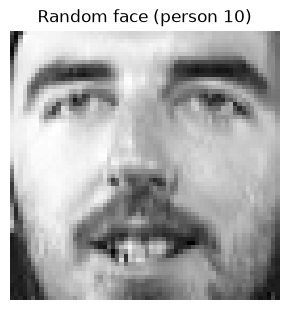

In [5]:
# Select one row from X randomly, reshape it to a 64*64 matrix then display it as a picture
idx = np.random.randint(X.shape[0])
plt.figure(figsize=(3.5, 3.5))
plt.imshow(X[idx].reshape(64, 64), cmap='gray')
plt.title(f"Random face (person {y[idx]})")
plt.axis('off')
plt.show()

### 5. Split the data into training and test datasets
- Keep the input samples as vectors and not reshape them to images

In [6]:
# split into 70% train and 30% test (samples kept as vectors)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
print(X_train.shape, X_test.shape)

(280, 4096) (120, 4096)


### 6. Implemente Logistic Regression using Scikit-learn library
#### 6.1. Train the model on the training set using 10-fold cross-validation startegy and evaluate it on the test set.

In [8]:
# training on training set
lr = LogisticRegression(max_iter=2000)

# 10-fold cross-validation on the training set (KFold, since each class has only 7 train samples)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=kf)
print(f"10-fold CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

lr.fit(X_train, y_train)

# Evaluation on test set
y_pred = lr.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

10-fold CV accuracy: 0.9393 (+/- 0.0506)


Test accuracy: 0.9750


#### 6.2. Display the classification report 

In [9]:
# Classification report, f-score, recall and precision, all in a table called classification_report
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
classification_report_table = pd.DataFrame(report_dict).transpose().round(3)
classification_report_table.tail(3)   # accuracy / macro avg / weighted avg summary rows

,precision,recall,f1-score,support
accuracy,0.975,0.975,0.975,0.975
macro avg,0.981,0.975,0.972,120.000
weighted avg,0.981,0.975,0.972,120.000


### 7. Implemente Logistic Regression using Keras or Pytorch (your choice)
1. Use one input layer for features and one output layer for prediction. The number of nodes in each layer depends on the number of features and the number of classes respectively.
2. Construct the model.
3. Define the optimizer (SGD, ADAM, ...) with its parameters.
4. Compile and fit the model to the training set using 10-fold cross validation strategy.
5. Evaluate the model on the test set and show the classification report.

In [10]:
# --- shared neural-network setup (features standardised; fit on training set only) ---
scaler = StandardScaler().fit(X_train)
Xtr_t = torch.tensor(scaler.transform(X_train), dtype=torch.float32)
Xte_t = torch.tensor(scaler.transform(X_test),  dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.long)
yte_t = torch.tensor(y_test,  dtype=torch.long)

n_features = X.shape[1]            # 4096 input nodes
n_classes  = len(np.unique(y))    # 40 output nodes

def build_model(hidden_layers=[]):
    """Logistic regression is a single Linear layer (hidden_layers=[]); add layers for an MLP."""
    layers, prev = [], n_features
    for h in hidden_layers:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers += [nn.Linear(prev, n_classes)]
    return nn.Sequential(*layers)

def make_optimizer(name, params):
    return {"SGD":     lambda: optim.SGD(params, lr=0.05, momentum=0.9),
            "Adam":    lambda: optim.Adam(params, lr=1e-3),
            "RMSprop": lambda: optim.RMSprop(params, lr=1e-3),
            "Adagrad": lambda: optim.Adagrad(params, lr=1e-2)}[name]()

def train_model(model, Xt, yt, optimizer_name="Adam", epochs=200):
    opt = make_optimizer(optimizer_name, model.parameters())
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(Xt), yt); loss.backward(); opt.step()
    return model

def evaluate(model, Xt, yt):
    model.eval()
    with torch.no_grad():
        return (model(Xt).argmax(1) == yt).float().mean().item()

# training on training set
# Logistic regression: input layer (4096) -> output layer (40), optimizer = Adam, 10-fold CV
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_acc = []
for tr_idx, va_idx in kfold.split(Xtr_t):
    torch.manual_seed(42)
    m = train_model(build_model([]), Xtr_t[tr_idx], ytr_t[tr_idx])
    cv_acc.append(evaluate(m, Xtr_t[va_idx], ytr_t[va_idx]))
print(f"PyTorch logistic regression - 10-fold CV accuracy: {np.mean(cv_acc):.4f}")

torch.manual_seed(42)
torch_lr = train_model(build_model([]), Xtr_t, ytr_t)

# evaluation on test set
with torch.no_grad():
    nn_pred = torch_lr(Xte_t).argmax(1).numpy()
print(f"PyTorch logistic regression - test accuracy: {accuracy_score(y_test, nn_pred):.4f}\n")
print(classification_report(y_test, nn_pred, zero_division=0))

PyTorch logistic regression - 10-fold CV accuracy: 0.9321


PyTorch logistic regression - test accuracy: 0.9583

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.67      0.80         3
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.33      0.50         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.75      1.00      0.86         3
          16       1.00     

#### 7.2. Add some hidden layers (with different number of nodes each) between the input and the output layers. Train and evaluate the model as in previous question.

In [11]:
# Add hidden layers (512 and 128 nodes) between the input and output layers
torch.manual_seed(42)
mlp = train_model(build_model([512, 128]), Xtr_t, ytr_t)

with torch.no_grad():
    mlp_pred = mlp(Xte_t).argmax(1).numpy()
print(f"MLP with hidden layers [512, 128] - test accuracy: {accuracy_score(y_test, mlp_pred):.4f}\n")
print(classification_report(y_test, mlp_pred, zero_division=0))

MLP with hidden layers [512, 128] - test accuracy: 0.9500

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.67      0.80         3
           5       0.75      1.00      0.86         3
           6       0.75      1.00      0.86         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.33      0.50         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      0.67      0.80         3
          13       1.00      1.00      1.00         3
          14       0.75      1.00      0.86         3
          15       1.00      1.00      1.00         3
          16       1.0

#### 7.3. Analyse the perfromance of the model with respect to the number of hidden layers.
#### a) Using Bar plot, show the accuracy vs the number of hidden layers.

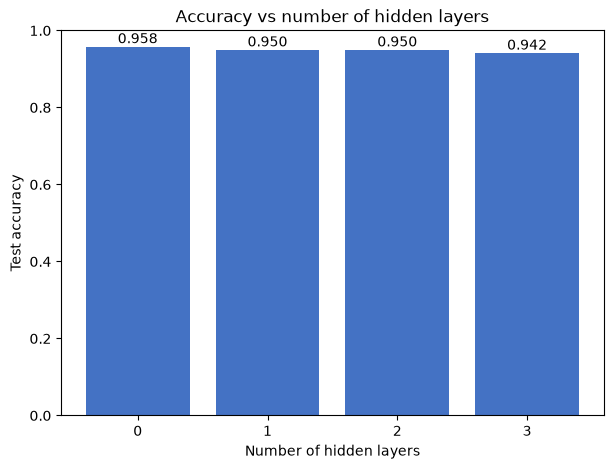

In [12]:
# Accuracy vs number of hidden layers (0 = plain logistic regression)
hidden_configs = {0: [], 1: [256], 2: [512, 128], 3: [512, 256, 128]}
layer_acc = {}
for n_layers, hidden in hidden_configs.items():
    torch.manual_seed(42)
    m = train_model(build_model(hidden), Xtr_t, ytr_t)
    layer_acc[n_layers] = evaluate(m, Xte_t, yte_t)

plt.figure(figsize=(7, 5))
bars = plt.bar([str(k) for k in layer_acc], list(layer_acc.values()), color="#4472C4")
plt.bar_label(bars, fmt="%.3f")
plt.xlabel("Number of hidden layers"); plt.ylabel("Test accuracy")
plt.title("Accuracy vs number of hidden layers"); plt.ylim(0, 1)
plt.show()

### 8. Analyse the performance of the model with respect to the optimizer
#### 8.1. Use different types of optimizers anb show the results using Bar plot.

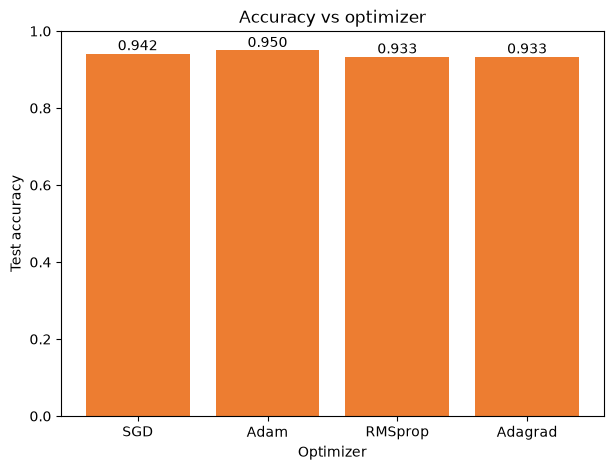

In [13]:
# Accuracy vs optimizer (fixed architecture: one hidden layer of 256 nodes)
opt_acc = {}
for name in ["SGD", "Adam", "RMSprop", "Adagrad"]:
    torch.manual_seed(42)
    m = train_model(build_model([256]), Xtr_t, ytr_t, optimizer_name=name)
    opt_acc[name] = evaluate(m, Xte_t, yte_t)

plt.figure(figsize=(7, 5))
bars = plt.bar(list(opt_acc), list(opt_acc.values()), color="#ED7D31")
plt.bar_label(bars, fmt="%.3f")
plt.xlabel("Optimizer"); plt.ylabel("Test accuracy")
plt.title("Accuracy vs optimizer"); plt.ylim(0, 1)
plt.show()

### 9. Reduce the dimesnionality of the problem using PCA.
#### 9.1. Use the 2 first principal component and plot the data scatter of the training set.

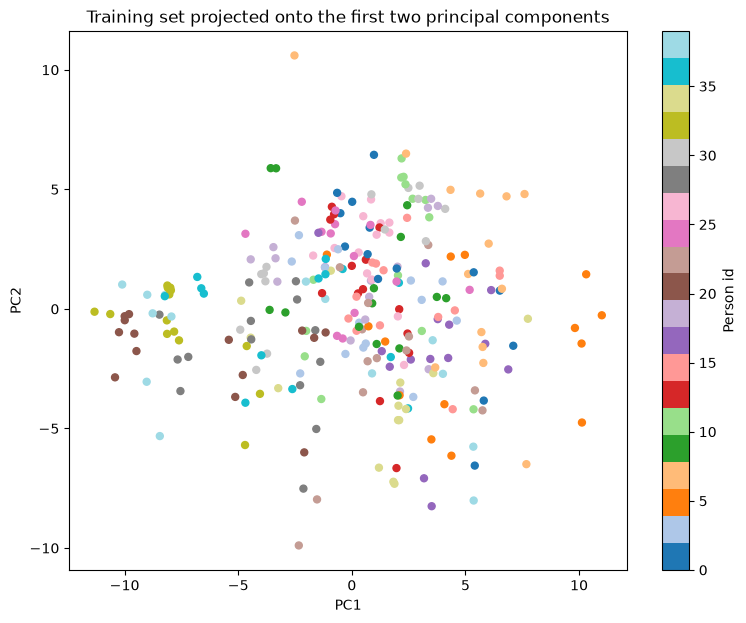

In [14]:
# First two principal components of the training set
pca2 = PCA(n_components=2, random_state=42).fit(X_train)
proj = pca2.transform(X_train)

plt.figure(figsize=(9, 7))
sc = plt.scatter(proj[:, 0], proj[:, 1], c=y_train, cmap="tab20", s=25)
plt.colorbar(sc, label="Person id")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Training set projected onto the first two principal components")
plt.show()

#### 9.2. Analyse the performance of the Logistic Regression model (using Scikit-learn package) with respect to the number of principal components used, for example (2,3,4,...10). Show the results using Bar plot.

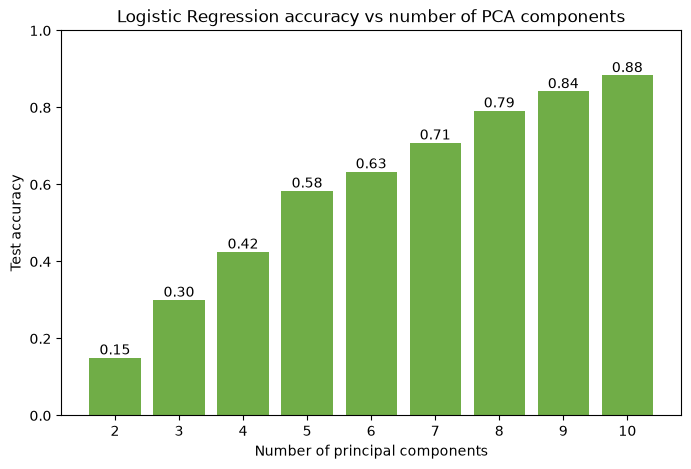

In [15]:
# Logistic Regression (Scikit-learn) accuracy vs number of principal components
pc_acc = {}
for k in range(2, 11):
    pca = PCA(n_components=k, random_state=42).fit(X_train)
    m = LogisticRegression(max_iter=2000).fit(pca.transform(X_train), y_train)
    pc_acc[k] = accuracy_score(y_test, m.predict(pca.transform(X_test)))

plt.figure(figsize=(8, 5))
bars = plt.bar([str(k) for k in pc_acc], list(pc_acc.values()), color="#70AD47")
plt.bar_label(bars, fmt="%.2f")
plt.xlabel("Number of principal components"); plt.ylabel("Test accuracy")
plt.title("Logistic Regression accuracy vs number of PCA components"); plt.ylim(0, 1)
plt.show()